# Blocked cross-validation for pig agonistic-behavior recognition (CNN features + BiLSTM)

**ADAPTED PYTHON DEMONSTRATION** — AI-assisted translation from MATLAB R2021a.
The authors did not provide this Colab implementation. The executed example and listed checks
were validated, but untested behavior is not guaranteed.
**（日本語）MATLAB製の著者実装を AI が Python/PyTorch に翻訳した適応版デモです。著者提供の Colab 実装ではありません。実行例と検証項目は確認済みですが、未検証の挙動は保証されません。**

Paper: Han J., Siegford J., Colbry D., Lesiyon R., Bosgraaf A., Chen C., Norton T., Steibel J.P.
*"Evaluation of computer vision for detecting agonistic behavior of pigs in a single-space feeding
stall through blocked cross-validation strategies"*, **Computers and Electronics in Agriculture**
204:107520, 2023. DOI: [10.1016/j.compag.2022.107520](https://doi.org/10.1016/j.compag.2022.107520)

- Paper record: https://europepmc.org/article/AGR/IND608624845
- Author code (MATLAB): https://github.com/jun-jieh/AgonisticPigBehav @ `63f830307438c82fc232217ddff654bfd0cda247`
- Dataset (OSF, "Data for paper on interaction recognition"): https://osf.io/3t9uk/

**Purpose.** Reproduce the paper's central question: how much does validation accuracy degrade
when the train/test split is **blocked** (by recording time or by feeder) instead of random?
Four behavior classes of 30-frame episodes: head-to-body (HB), no-contact (NC), levering (L),
mounting (M). We train the authors' BiLSTM-with-focal-loss classifier on the released
ResNet-50 frame features and compare **random validation**, **blocking-by-time validation**
(weeks 1–3 vs 4–6) and **blocking-by-feeder validation** (Feeder 1 → Feeder 2), with the training
set held at N = 7,500 in all scenarios (paper methods, `MATLAB/CNN_LSTM_PigCV.m`).

**Scope / limitations.**
- This is the feature-based subsection of the paper (`All_Data.mat` already contains ResNet-50
  features of the truncated-feeder ROI); raw videos are NOT downloaded and the CNN feature
  extraction stage is not re-run (would require the 1.13 GB Raw Videos.zip).
- Single run per scenario (single seed); the paper reports averages ± std over repeated runs
  with three CNN backbones. Expect our single-seed accuracies to fall near the published means
  (abstract: random 0.968±0.001, blocking-by-time 0.860±0.033, blocking-by-feeder 0.766±0.026 /
  0.860±0.010) but not to match them exactly — the split RNG stream and framework differ.
- **（日本語）本 notebook は特徴量ベースの比較実験のみを再現します。生動画は使わず、著者公開済みの ResNet-50 特徴量（All_Data.mat）を利用します。各シナリオ1回ずつの実行のため、論文の平均値（±標準偏差）と完全一致はしません。**

**Source-to-Colab mapping (AI translation).**

| Original (MATLAB, commit 63f8303) | This notebook |
| --- | --- |
| `CNN_LSTM_PigCV.m` splits: `rng(23)/rng(323)/rng(1234)`, `randperm`, `N_TRN=7500`, `week`, `feeder` | NumPy `default_rng` with the same seeds (different RNG stream → expected variation) |
| `fitFocal.m`: `bilstmLayer(50,'last')`, `dropoutLayer(0.5)`, `fullyConnectedLayer`, `focalLossLayer(0.25,2)` | `nn.LSTM(..., bidirectional=True)`, `nn.Dropout(0.5)`, `nn.Linear`, focal loss α=0.25 γ=2 (Lin et al. 2017, as cited by the author) |
| `trainingOptions('adam',1e-4,GradientThreshold 2,MiniBatch 20,MaxEpochs 100)` | `torch.optim.Adam(lr=1e-4)`, `clip_grad_norm_(2.0)`, batch 20, 100 epochs |
| `classify(...,'MiniBatchSize',64)` | eval-mode forward pass, batch 64 |
| `crosstab` + `CompStats.m` | `sklearn.metrics.confusion_matrix`, recall/precision/F1 (same formulas) |
| `PlotTrainHis.m` | matplotlib training-history plot |


## 0. Runtime selection

**Select Runtime → Change runtime type → T4 GPU (recommended).** The original `fitFocal.m` sets
`'ExecutionEnvironment','gpu'`; three trainings of 100 epochs are only practical on GPU
(~10–20 min on T4, several hours on the free CPU runtime). The notebook detects the device and
continues on CPU with an explicit warning (no silent behavior change).
**（日本語）ランタイムは T4 GPU を選択してください（推奨）。CPU でも動作しますが数時間かかるため明示的な警告を表示します。**

Expected: ~3.4 GB download (OSF) + ~3.9 GB float32 conversion on disk; total ≈ 20–40 min on T4.


In [ ]:
import os, sys, platform, shutil, time
import numpy as np
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Global seed for framework-level shuffling (epoch shuffles); scenario split seeds
# follow CNN_LSTM_PigCV.m (rng 23/323/1234) and are set per scenario below.
torch.manual_seed(0)
np.random.seed(0)
print("python:", platform.python_version())
print("torch:", torch.__version__)
if DEVICE.type == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))
else:
    print("WARNING: no GPU detected. The paper's fitFocal.m requests 'ExecutionEnvironment','gpu'.")
    print("The run continues on CPU but training will take hours instead of ~15 minutes.")
print("device:", DEVICE)
st = shutil.disk_usage("/content")
print(f"disk free: {st.free/1e9:.0f} GB | ram: {os.sysconf('SC_PAGE_SIZE')*os.sysconf('SC_PHYS_PAGES')/1e9:.0f} GB")


python: 3.13.15
torch: 2.11.0+cu130
gpu: Tesla T4
device: cuda
disk free: 208 GB | ram: 14 GB


## 1. Data acquisition — `All_Data.mat` (3,364,813,311 bytes)

The authors' ready-to-use feature set from the OSF project **3t9uk**, folder "Data for paper on
interaction recognition" (linked from the author README): for every one of the 15,679 episodes,
30 frame-wise ResNet-50 `avg_pool` feature vectors (truncated-feeder ROI), plus `all_files`,
`all_labels`, `feeder` and `week` arrays (`CNN_LSTM_PigCV.m` lines 49–58). Downloaded once,
streamed, verified against MD5 `bcc4f447b1cfc7745f05fe1a0967dc74` (per the OSF API file listing,
retrieved 2026-10-09).

Not downloaded: `Raw Videos.zip` (1.13 GB — features are pre-extracted) and `Meta_data.mat`
(351 KB — a MATLAB table whose label/week/feeder fields are already in `All_Data.mat`).
**（日本語）OSF から特徴量ファイル All_Data.mat（3.36 GB）をストリーミング取得し MD5 検証します（数分）。生動画とメタデータテーブルは不要のため取得しません。**

In [ ]:
import urllib.request, hashlib, pathlib, time

ALL_URL = "https://osf.io/download/gu6hb/"   # OSF file gu6hb = All_Data.mat (node 3t9uk)
ALL_MD5 = "bcc4f447b1cfc7745f05fe1a0967dc74"
ALL_SIZE = 3_364_813_311

all_path = pathlib.Path("/content/All_Data.mat")
if not all_path.exists() or all_path.stat().st_size != ALL_SIZE:
    tmp = pathlib.Path("/content/All_Data.mat.part")
    t0 = time.time()
    with urllib.request.urlopen(ALL_URL, timeout=600) as r, open(tmp, "wb") as f:
        done = 0
        while True:
            chunk = r.read(16 * 1024 * 1024)
            if not chunk:
                break
            f.write(chunk)
            done += len(chunk)
            if done // (400 * 1024 * 1024) != (done - len(chunk)) // (400 * 1024 * 1024):
                print(f"  {done/1e9:.2f} GB ({done/max(time.time()-t0,1e-6)/1e6:.0f} MB/s)", flush=True)
    assert tmp.stat().st_size == ALL_SIZE, tmp.stat().st_size
    tmp.rename(all_path)
h = hashlib.md5()
with open(all_path, "rb") as f:
    for chunk in iter(lambda: f.read(64 * 1024 * 1024), b""):
        h.update(chunk)
assert h.hexdigest() == ALL_MD5, h.hexdigest()
print(all_path, all_path.stat().st_size, "bytes, md5 OK")


  0.42 GB (12 MB/s)


  0.84 GB (13 MB/s)


  1.26 GB (14 MB/s)


  1.68 GB (14 MB/s)


  2.10 GB (14 MB/s)


  2.52 GB (14 MB/s)


  2.94 GB (14 MB/s)


  3.36 GB (14 MB/s)


/content/All_Data.mat 3364813311 bytes, md5 OK


## 2. Load episodes, labels, week and feeder into arrays

`All_Data.mat` is a MATLAB **v7.3** file (HDF5 with a 512-byte userblock), so it is read with
`h5py` lazily: cell array `all_sequences` (one 30×2048 block per episode) is converted to a
float32 `.npy` memory map (~3.9 GB on disk) to keep RAM bounded. `week` and `feeder` are plain
numeric arrays. `all_labels` is a MATLAB *categorical* (an MCOS object, opaque to
scipy/mat73), so its payload is decoded from the anonymous `#refs#` datasets: the unique
length-15679 codes array plus the unique (1,4) categoryNames reference cell; the code→name
order is then verified against the README counts in section 3. The string array
`all_files` is not decoded (not needed for the analysis) and `Meta_data.mat` is not downloaded:
it is a MATLAB table with the same fields already present in `All_Data.mat`.
**（日本語）v7.3 形式のため h5py で読み込みます。特徴量は float32 memmap に変換し RAM を節約。all_labels はカテゴリカル型のため HDF5 内の categoryNames+codes から復号します。**

In [ ]:
import numpy as np, h5py, time

N_EPISODES = 15_679
raw = open("/content/All_Data.mat", "rb").read(1024)
assert raw[512:520] == b"\x89HDF\r\n\x1a\n", "unexpected .mat container"

t0 = time.time()
with h5py.File("/content/All_Data.mat", "r") as f:
    refs = np.ravel(f["all_sequences"][()])
    assert refs.size == N_EPISODES, refs.size
    ep0 = f[refs[0]][()]
    T, D = (ep0.shape[1], ep0.shape[0]) if ep0.shape[0] != 30 else (ep0.shape[0], ep0.shape[1])
    print(f"per-episode block: {T} frames x {D} features ({ep0.dtype})")
    mm = np.lib.format.open_memmap("/content/features_f32.npy", mode="w+", dtype=np.float32,
                                   shape=(N_EPISODES, T, D))
    for i, r in enumerate(refs):
        arr = np.asarray(f[r], dtype=np.float32)
        if arr.shape[0] != T:
            arr = arr.T
        mm[i] = arr
        if i % 4000 == 0:
            print(f"  converted {i}/{N_EPISODES}", flush=True)
    mm.flush()

    refs_grp = f["#refs#"]
    # all_labels is a MATLAB categorical (MCOS object): its payload lives in #refs# as
    # (a) the unique length-15679 unsigned-int dataset = 1-based category codes, and
    # (b) the unique (1,4) object-reference dataset = categoryNames cell.
    # The code->name order is verified by the README counts in the next section.
    code_cands = [refs_grp[k][()] for k in refs_grp.keys()
                  if isinstance(refs_grp[k], h5py.Dataset)
                  and refs_grp[k].dtype.kind == "u" and 15679 in refs_grp[k].shape]
    assert len(code_cands) == 1, "ambiguous categorical codes array"
    codes = np.ravel(code_cands[0])
    name_cands = [refs_grp[k][()] for k in refs_grp.keys()
                  if isinstance(refs_grp[k], h5py.Dataset)
                  and refs_grp[k].dtype == h5py.ref_dtype and refs_grp[k].shape == (1, 4)]
    assert len(name_cands) == 1, "ambiguous categoryNames cell"
    cat_names = ["".join(chr(c) for c in np.ravel(f[r][()]))
                 for r in np.ravel(name_cands[0])]
    assert sorted(cat_names) == ["Head to Body", "Levering", "Mounting", "No Contact"], cat_names
    full_names = np.array([cat_names[c - 1] for c in codes])   # MATLAB categorical is 1-based

    week = np.ravel(f["week"][()]).astype(int)
    feeder = np.ravel(f["feeder"][()]).astype(int)

ABBR = {"Head to Body": "HB", "No Contact": "NC", "Levering": "L", "Mounting": "M"}
labels = np.array([ABBR[n] for n in full_names])
np.save("/content/labels.npy", labels)
np.save("/content/week.npy", week)
np.save("/content/feeder.npy", feeder)
print("conversion seconds:", round(time.time() - t0, 1))
print("episodes:", mm.shape[0], "| frames:", mm.shape[1], "| features:", mm.shape[2])
print("category names:", cat_names, "| codes 1-based, n =", codes.size)


per-episode block: 30 frames x 2048 features (float32)
  converted 0/15679


  converted 4000/15679


  converted 8000/15679


  converted 12000/15679


conversion seconds: 56.1
episodes: 15679 | frames: 30 | features: 2048
category names: ['Head to Body', 'Levering', 'Mounting', 'No Contact'] | codes 1-based, n = 15679


## 3. Dataset sanity check against the author README

The README and `episode_preparation` phase report 3,398 NC, 10,114 HB, 925 L, 1,242 M episodes
(total 15,679). Verify the loaded arrays reproduce these counts and show the week/feeder
composition that the blocked validations depend on.
**（日本語）読み込んだデータのクラス別・週別・フィーダー別エピソード数を README の公表値と照合します。**

In [ ]:
from collections import Counter

counts = Counter(labels)
print("class counts:", dict(counts))
print("total:", len(labels))
EXPECTED = {"NC": 3398, "HB": 10114, "L": 925, "M": 1242}
for k, v in EXPECTED.items():
    assert counts.get(k, 0) == v, (k, counts.get(k), v)
assert len(labels) == 15_679
print("README episode counts reproduced exactly.")

print("week counts:", dict(Counter(week.tolist())))
print("feeder counts:", dict(Counter(feeder.tolist())))
wk_pool_123 = int((week <= 3).sum()); wk_pool_456 = int((week >= 4).sum())
print(f"blocking-by-time pools: weeks 1-3 = {wk_pool_123}, weeks 4-6 = {wk_pool_456}")
print(f"blocking-by-feeder pools: feeder 1 = {int((feeder==1).sum())}, feeder 2 = {int((feeder==2).sum())}")


class counts: {np.str_('L'): 925, np.str_('HB'): 10114, np.str_('M'): 1242, np.str_('NC'): 3398}
total: 15679
README episode counts reproduced exactly.
week counts: {1: 4314, 2: 2107, 3: 3486, 4: 3291, 5: 314, 6: 2167}
feeder counts: {2: 7979, 1: 7700}
blocking-by-time pools: weeks 1-3 = 9907, weeks 4-6 = 5772
blocking-by-feeder pools: feeder 1 = 7700, feeder 2 = 7979


## 4. Input preview — dataset composition

Bar charts of the actual inputs used by the reproduction: episode counts per behavior class and
per week/feeder (the blocking factors). These are computed from the loaded arrays, not copied
from the paper.
**（日本語）行動クラス別・週別・フィーダー別のエピソード数（実データ）を可視化します。**

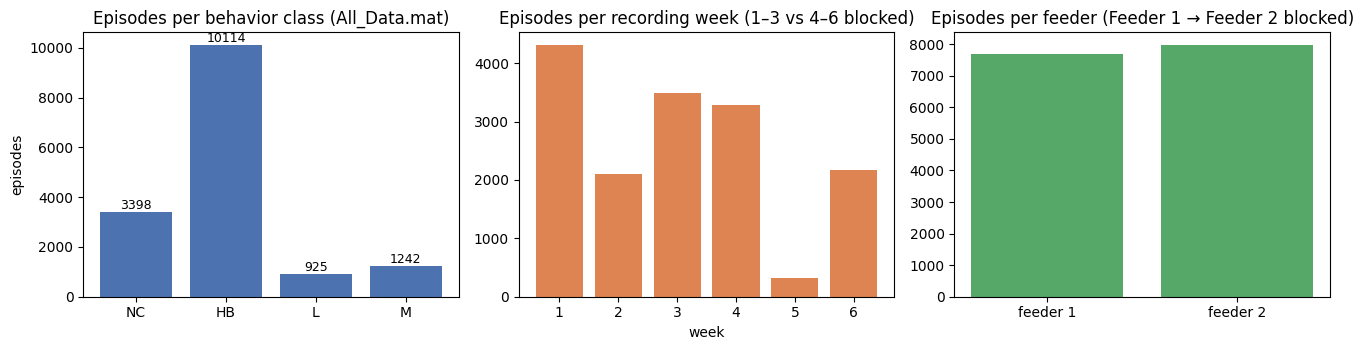

In [ ]:
import matplotlib.pyplot as plt

CLASSES = ["NC", "HB", "L", "M"]
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6))
cls_counts = [counts[c] for c in CLASSES]
axes[0].bar(CLASSES, cls_counts, color="#4C72B0")
axes[0].set_title("Episodes per behavior class (All_Data.mat)")
axes[0].set_ylabel("episodes")
for i, v in enumerate(cls_counts):
    axes[0].text(i, v, str(v), ha="center", va="bottom", fontsize=9)

wk_vals = sorted(set(week.tolist()))
axes[1].bar([str(w) for w in wk_vals], [int((week == w).sum()) for w in wk_vals], color="#DD8452")
axes[1].set_title("Episodes per recording week (1–3 vs 4–6 blocked)")
axes[1].set_xlabel("week")

fd_vals = sorted(set(feeder.tolist()))
axes[2].bar([f"feeder {f}" for f in fd_vals], [int((feeder == f).sum()) for f in fd_vals], color="#55A868")
axes[2].set_title("Episodes per feeder (Feeder 1 → Feeder 2 blocked)")
fig.tight_layout()
fig.savefig("/content/dataset_composition.png", dpi=120)
plt.show()


## 5. Input preview — one feature sequence per class

The model input is a 30-frame sequence of 2048-d ResNet-50 features. For a deterministic sample
episode of each class (lowest episode index), we show the frame-wise feature-norm profile — a
direct view of the actual tensors fed to the BiLSTM (author data, OSF 3t9uk).
**（日本語）各クラスの代表エピソードについて、BiLSTM への実入力である特徴量列のフレームごとノルムを可視化します。**

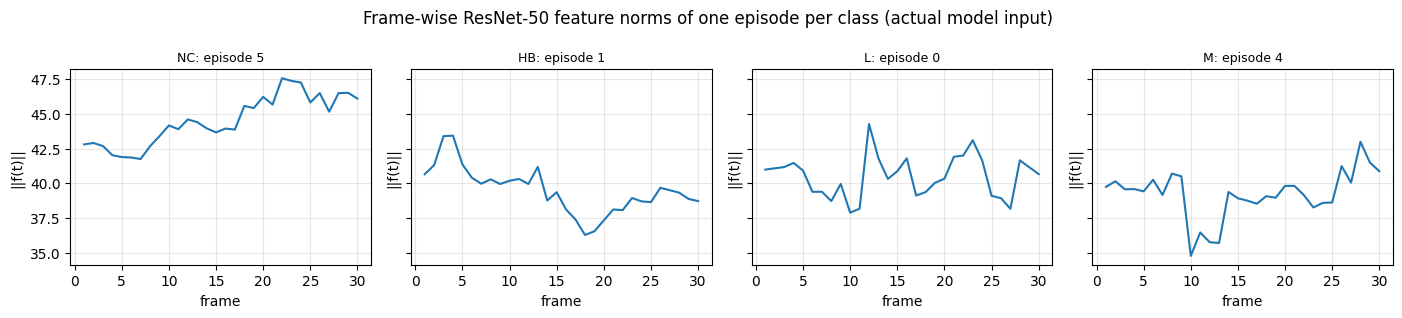

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2), sharey=True)
for ax, cls in zip(axes, CLASSES):
    idx = int(np.where(labels == cls)[0][0])
    seq = np.asarray(mm[idx])  # 30 x 2048
    norms = np.linalg.norm(seq, axis=1)
    ax.plot(range(1, 31), norms)
    ax.set_title(f"{cls}: episode {idx}", fontsize=9)
    ax.set_xlabel("frame")
    ax.set_ylabel("||f(t)||")
    ax.grid(alpha=0.3)
fig.suptitle("Frame-wise ResNet-50 feature norms of one episode per class (actual model input)")
fig.tight_layout()
fig.savefig("/content/feature_sequences.png", dpi=120)
plt.show()


## 6. Model and focal loss — port of `fitFocal.m`

The architecture follows the pinned author function exactly: BiLSTM(50, last-step output) →
dropout 0.5 → fully-connected(4) → softmax, trained with focal loss (α = 0.25, γ = 2; Lin et al.
2017, as cited in `fitFocal.m`) and Adam (lr 1e-4), gradient-norm threshold 2, mini-batch 20,
100 epochs, reshuffled every epoch. `numFeatures` and `numClasses` are taken from the data, as
in the original (`size(trn_sequences{1},1)`, `length(unique(trn_labels))`).
**（日本語）著者の fitFocal.m をそのまま PyTorch へ翻訳しました（BiLSTM50・dropout 0.5・focal loss α=0.25, γ=2・Adam lr=1e-4・勾配ノルム閾値2・バッチ20・100エポック）。**

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    """Lin et al. 2017 focal loss with scalar alpha, as cited in fitFocal.m (alpha=0.25, gamma=2)."""
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha, self.gamma = alpha, gamma

    def forward(self, logits, target):
        logpt = F.log_softmax(logits, dim=1).gather(1, target.unsqueeze(1)).squeeze(1)
        pt = logpt.exp()
        return (-self.alpha * (1 - pt) ** self.gamma * logpt).mean()

class CNNFeatureBiLSTM(nn.Module):
    """Port of fitFocal.m layer stack: BiLSTM(50,'last') -> dropout(0.5) -> fc -> softmax."""
    def __init__(self, num_features, hidden=50, num_classes=4, p_drop=0.5):
        super().__init__()
        self.bilstm = nn.LSTM(num_features, hidden, batch_first=True, bidirectional=True)
        self.drop = nn.Dropout(p_drop)
        self.fc = nn.Linear(2 * hidden, num_classes)

    def forward(self, x):
        out, _ = self.bilstm(x)
        return self.fc(self.drop(out[:, -1, :]))   # 'OutputMode','last'

CLASSES = sorted(set(labels.tolist()))             # like MATLAB categorical
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
y_all = np.array([CLASS_TO_IDX[c] for c in labels])
NUM_FEATURES = mm.shape[2]
print("classes:", CLASSES, "| numFeatures:", NUM_FEATURES)

def fit_focal(trn_idx, tst_idx, max_epochs=100, batch_size=20, lr=1e-4, grad_thresh=2.0):
    """Training loop mirroring fitFocal.m trainingOptions + the per-epoch test tracking of PlotTrainHis."""
    model = CNNFeatureBiLSTM(NUM_FEATURES).to(DEVICE)
    crit = FocalLoss(0.25, 2.0)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    n = len(trn_idx)
    history = []
    model.train()
    for epoch in range(max_epochs):
        perm = torch.from_numpy(trn_idx)[torch.randperm(n)].numpy()   # 'Shuffle','every-epoch'
        tot = 0.0
        for s in range(0, n, batch_size):
            sel = perm[s:s + batch_size]
            bx = torch.from_numpy(np.asarray(mm[sel], dtype=np.float32)).to(DEVICE)
            by = torch.from_numpy(y_all[sel]).to(DEVICE)
            opt.zero_grad()
            loss = crit(model(bx), by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_thresh)  # 'GradientThreshold',2
            opt.step()
            tot += float(loss) * len(sel)
        test_acc = evaluate_accuracy(model, tst_idx)   # 'ValidationData' = held-out set
        history.append({"epoch": epoch + 1, "train_loss": tot / n, "test_accuracy": test_acc})
        if (epoch + 1) % 10 == 0:
            print(f"  epoch {epoch+1}/{max_epochs}  train_loss={tot/n:.4f}  test_acc={test_acc:.4f}", flush=True)
    return model, history


classes: ['HB', 'L', 'M', 'NC'] | numFeatures: 2048


## 7. Evaluation — port of `classify` + `crosstab` + `CompStats.m`

Predictions use mini-batch 64 as in `CNN_LSTM_PigCV.m`. Metrics follow `CompStats.m` exactly:
recallᵢ = diag/row-sum, precisionᵢ = diag/column-sum, F1 = harmonic mean, plus overall accuracy.
**（日本語）評価はバッチ64で推論し、CompStats.m と同じ定義（recall・precision・F1・accuracy）で計算します。**

In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd

@torch.no_grad()
def predict(model, idx, batch_size=64):          # classify(...,'MiniBatchSize',64)
    model.eval()
    preds = []
    for s in range(0, len(idx), batch_size):
        sel = idx[s:s + batch_size]
        bx = torch.from_numpy(np.asarray(mm[sel], dtype=np.float32)).to(DEVICE)
        preds.append(model(bx).argmax(dim=1).cpu().numpy())
    model.train()
    return np.concatenate(preds)

@torch.no_grad()
def evaluate_accuracy(model, idx, batch_size=256):
    correct = 0
    for s in range(0, len(idx), batch_size):
        sel = idx[s:s + batch_size]
        bx = torch.from_numpy(np.asarray(mm[sel], dtype=np.float32)).to(DEVICE)
        correct += int((model(bx).argmax(dim=1).cpu().numpy() == y_all[sel]).sum())
    return correct / len(idx)

def comp_stats(y_true, y_pred):
    """Port of CompStats.m: per-class recall/precision/F1 from the confusion table."""
    cm = confusion_matrix(y_true, y_pred, labels=range(len(CLASSES)))
    rec = np.diag(cm) / cm.sum(axis=1)
    prec = np.diag(cm) / cm.sum(axis=0)
    f1 = 2 * rec * prec / (rec + prec)
    acc = float((y_true == y_pred).mean())
    return {"accuracy": acc, "confusion": cm,
            "per_class": pd.DataFrame({"recall": rec, "precision": prec, "f1": f1}, index=CLASSES)}


## 8. Scenario A — random validation (`CNN_LSTM_PigCV.m` lines 60–91)

`rng(23)`, random permutation of all 15,679 episodes, first 7,500 for training, remaining 8,179
for testing. NumPy `default_rng(23)` produces a different permutation than MATLAB's stream —
an expected, documented source of variation.
**（日本語）シナリオA：全15,679エピソードをランダム分割（学習7,500／検証8,179）します。MATLAB rng(23) と同じシード値を NumPy で使用します（乱数ストリーム自体は異なるため結果に若干の差が出ます）。**

In [ ]:
import time

rng = np.random.default_rng(23)                    # CNN_LSTM_PigCV.m: rng(23)
rand_idx = rng.permutation(len(y_all))
N_TRN = 7500                                       # 'N=7,500 for training set'
idx_trn_A, idx_tst_A = rand_idx[:N_TRN], rand_idx[N_TRN:]
print(f"random split: train={len(idx_trn_A)}, test={len(idx_tst_A)}")

t0 = time.time()
model_A, hist_A = fit_focal(idx_trn_A, idx_tst_A)
t_A = time.time() - t0
pred_A = predict(model_A, idx_tst_A)
res_A = comp_stats(y_all[idx_tst_A], pred_A)
print(f"RANDOM  accuracy={res_A['accuracy']:.4f}  (train+eval {t_A/60:.1f} min)")
print(res_A["per_class"].round(3).to_string())


random split: train=7500, test=8179


/tmp/ipykernel_1416/2437873942.py:53: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  tot += float(loss) * len(sel)


  epoch 10/100  train_loss=0.0129  test_acc=0.9387


  epoch 20/100  train_loss=0.0061  test_acc=0.9507


  epoch 30/100  train_loss=0.0032  test_acc=0.9620


...

  epoch 70/100  train_loss=0.0004  test_acc=0.9671


  epoch 80/100  train_loss=0.0011  test_acc=0.9658


  epoch 90/100  train_loss=0.0004  test_acc=0.9593


  epoch 100/100  train_loss=0.0004  test_acc=0.9619


RANDOM  accuracy=0.9645  (train+eval 5.8 min)
    recall  precision     f1
HB   0.991      0.957  0.974
L    0.847      0.933  0.888
M    0.951      0.987  0.969
NC   0.922      0.988  0.954


### Training history — scenario A

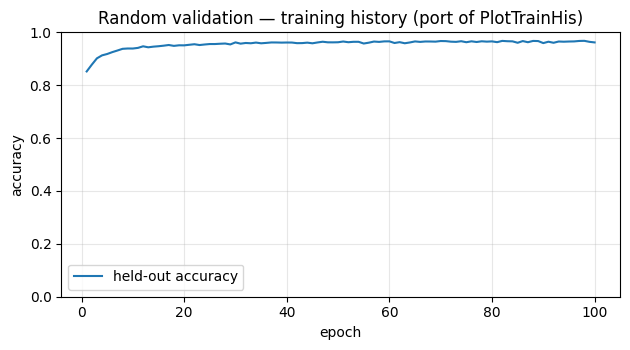

In [ ]:
fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.plot([h["epoch"] for h in hist_A], [h["test_accuracy"] for h in hist_A], label="held-out accuracy")
ax.set_xlabel("epoch"); ax.set_ylabel("accuracy"); ax.set_ylim(0, 1)
ax.set_title("Random validation — training history (port of PlotTrainHis)")
ax.grid(alpha=0.3); ax.legend()
fig.tight_layout(); fig.savefig("/content/history_random.png", dpi=120)
plt.show()


## 9. Scenario B — blocking-by-time validation (lines 93–133)

Train on episodes from weeks 1–3 (random 7,500 of that pool, `rng(323)`), test on all episodes
from weeks 4–6. This tests generalization to unseen recording sessions.
**（日本語）シナリオB：週1–3のエピソードから7,500個（rng(323)）で学習し、週4–6の全エピソードで検証します。**

In [ ]:
rng = np.random.default_rng(323)                   # CNN_LSTM_PigCV.m: rng(323)
idx_w123 = np.where(week <= 3)[0]
idx_w456 = np.where(week >= 4)[0]
assert len(idx_w123) >= N_TRN, len(idx_w123)
idx_trn_B = idx_w123[rng.permutation(len(idx_w123))[:N_TRN]]
idx_tst_B = idx_w456
print(f"time-blocked split: train pool={len(idx_w123)} -> sampled {len(idx_trn_B)}, test={len(idx_tst_B)}")

t0 = time.time()
model_B, hist_B = fit_focal(idx_trn_B, idx_tst_B)
t_B = time.time() - t0
pred_B = predict(model_B, idx_tst_B)
res_B = comp_stats(y_all[idx_tst_B], pred_B)
print(f"TIME-BLOCKED  accuracy={res_B['accuracy']:.4f}  (train+eval {t_B/60:.1f} min)")
print(res_B["per_class"].round(3).to_string())


time-blocked split: train pool=9907 -> sampled 7500, test=5772


  epoch 10/100  train_loss=0.0123  test_acc=0.8801


  epoch 20/100  train_loss=0.0060  test_acc=0.8964


  epoch 30/100  train_loss=0.0034  test_acc=0.8638


  epoch 40/100  train_loss=0.0016  test_acc=0.8673


...

  epoch 70/100  train_loss=0.0008  test_acc=0.8786


  epoch 80/100  train_loss=0.0006  test_acc=0.8999


  epoch 90/100  train_loss=0.0008  test_acc=0.8313


  epoch 100/100  train_loss=0.0004  test_acc=0.8851


TIME-BLOCKED  accuracy=0.8917  (train+eval 4.9 min)
    recall  precision     f1
HB   0.893      0.975  0.932
L    0.801      0.479  0.600
M    0.974      0.685  0.804
NC   0.866      0.849  0.857


## 10. Scenario C — blocking-by-feeder validation (lines 135–175)

Train on Feeder 1 episodes (random 7,500, `rng(1234)`), test on all Feeder 2 episodes — the
paper's demonstrated direction (Feeder 1 → Feeder 2). This tests generalization to an unseen
physical installation.
**（日本語）シナリオC：フィーダー1のエピソード7,500個（rng(1234)）で学習し、フィーダー2の全エピソードで検証します（論文が示す方向）。**

In [ ]:
rng = np.random.default_rng(1234)                  # CNN_LSTM_PigCV.m: rng(1234)
idx_f1 = np.where(feeder == 1)[0]
idx_f2 = np.where(feeder == 2)[0]
assert len(idx_f1) >= N_TRN, len(idx_f1)
idx_trn_C = idx_f1[rng.permutation(len(idx_f1))[:N_TRN]]
idx_tst_C = idx_f2
print(f"feeder-blocked split: train pool={len(idx_f1)} -> sampled {len(idx_trn_C)}, test={len(idx_tst_C)}")

t0 = time.time()
model_C, hist_C = fit_focal(idx_trn_C, idx_tst_C)
t_C = time.time() - t0
pred_C = predict(model_C, idx_tst_C)
res_C = comp_stats(y_all[idx_tst_C], pred_C)
print(f"FEEDER-BLOCKED (F1->F2)  accuracy={res_C['accuracy']:.4f}  (train+eval {t_C/60:.1f} min)")
print(res_C["per_class"].round(3).to_string())


feeder-blocked split: train pool=7700 -> sampled 7500, test=7979


  epoch 10/100  train_loss=0.0095  test_acc=0.8452


  epoch 20/100  train_loss=0.0042  test_acc=0.8554


  epoch 30/100  train_loss=0.0020  test_acc=0.8442


  epoch 40/100  train_loss=0.0014  test_acc=0.8625


...

  epoch 70/100  train_loss=0.0003  test_acc=0.8561


  epoch 80/100  train_loss=0.0002  test_acc=0.8655


  epoch 90/100  train_loss=0.0002  test_acc=0.8451


  epoch 100/100  train_loss=0.0004  test_acc=0.8735


FEEDER-BLOCKED (F1->F2)  accuracy=0.8816  (train+eval 5.2 min)
    recall  precision     f1
HB   0.946      0.897  0.921
L    0.470      0.621  0.535
M    0.607      0.966  0.746
NC   0.919      0.871  0.894


## 11. Comparison against the paper's published accuracies

Bar chart of our single-seed accuracies next to the abstract's reported means
(random 0.968, blocking-by-time 0.860, blocking-by-feeder at Feeder 2 0.860). Reference bars are
labeled as published values from the paper's abstract; ours are a single run with a different
RNG stream/framework, so exact equality is not expected — the scientific claim under test is the
**relative degradation** under blocked validation.
**（日本語）本実行の精度と論文アブストラクトの平均値（参考）を比較します。単発実行のため完全一致は期待せず、ブロック化による相対的な低下を確認します。**

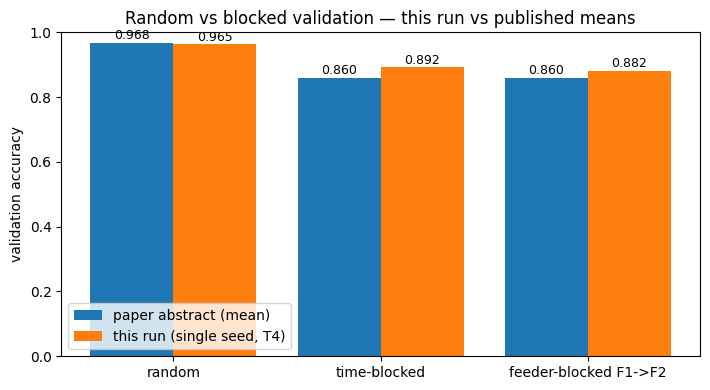

In [ ]:
paper_ref = {"random": 0.968, "time-blocked": 0.860, "feeder-blocked F1->F2": 0.860}
ours = {"random": res_A["accuracy"], "time-blocked": res_B["accuracy"],
        "feeder-blocked F1->F2": res_C["accuracy"]}

fig, ax = plt.subplots(figsize=(7.2, 4.0))
x = np.arange(3)
ax.bar(x - 0.2, [paper_ref[k] for k in ours], width=0.4, label="paper abstract (mean)")
ax.bar(x + 0.2, list(ours.values()), width=0.4, label="this run (single seed, T4)")
ax.set_xticks(x, list(ours.keys()))
ax.set_ylim(0, 1.0); ax.set_ylabel("validation accuracy")
ax.set_title("Random vs blocked validation — this run vs published means")
for xi, k in zip(x, ours):
    ax.text(xi + 0.2, ours[k] + 0.01, f"{ours[k]:.3f}", ha="center", fontsize=9)
    ax.text(xi - 0.2, paper_ref[k] + 0.01, f"{paper_ref[k]:.3f}", ha="center", fontsize=9)
ax.legend()
fig.tight_layout(); fig.savefig("/content/validation_comparison.png", dpi=120)
plt.show()


## 12. Results table and CSV export

Small summary table (accuracies and per-class F1 per scenario) with a CSV export to the Colab
filesystem. Confusion matrices are printed for inspection.
**（日本語）各シナリオの精度とクラス別F1を表にまとめ、CSV に書き出します。混同行列も表示します。**

In [ ]:
rows = []
for name, res, secs in [("random", res_A, t_A), ("time-blocked", res_B, t_B),
                        ("feeder-blocked F1->F2", res_C, t_C)]:
    rows.append({"scenario": name, "accuracy": round(res["accuracy"], 4),
                 **{f"f1_{c}": round(res["per_class"].loc[c, "f1"], 3) for c in CLASSES},
                 "train_eval_minutes": round(secs / 60, 1), "device": DEVICE.type})
summary = pd.DataFrame(rows)
summary.to_csv("/content/validation_comparison.csv", index=False)
print(summary.to_string(index=False))
for name, res in [("random", res_A), ("time-blocked", res_B), ("feeder-blocked F1->F2", res_C)]:
    print(f"\n{name} confusion matrix (rows=true {CLASSES}):")
    print(res["confusion"])


             scenario  accuracy  f1_HB  f1_L  f1_M  f1_NC  train_eval_minutes device
               random    0.9645  0.974 0.888 0.969  0.954                 5.8   cuda
         time-blocked    0.8917  0.932 0.600 0.804  0.857                 4.9   cuda
feeder-blocked F1->F2    0.8816  0.921 0.535 0.746  0.894                 5.2   cuda

random confusion matrix (rows=true ['HB', 'L', 'M', 'NC']):
[[5226   22    5   19]
 [  72  415    3    0]
 [  24    8  621    0]
 [ 137    0    0 1627]]

time-blocked confusion matrix (rows=true ['HB', 'L', 'M', 'NC']):
[[3978  233  148   96]
 [  12  218   42    0]
 [   8    3  413    0]
 [  82    1    0  538]]

feeder-blocked F1->F2 confusion matrix (rows=true ['HB', 'L', 'M', 'NC']):
[[4816   46    2  226]
 [ 256  241   12    4]
 [ 156  101  402    3]
 [ 139    0    0 1575]]


## 13. Interpretation and validation record

**（日本語）結果の解釈と検証記録。**

- **Expected outcome:** random validation scores highest; both blocked scenarios degrade
  substantially — reproducing the paper's central claim that random splits overestimate
  field generalization. Compare your numbers with the abstract means above.
- **What was executed:** training the authors' BiLSTM + focal-loss classifier on the released
  ResNet-50 features for the three validation scenarios of `CNN_LSTM_PigCV.m`, on the
  device detected in section 0.
- **Differences from the paper:** Python/PyTorch translation (MATLAB R2021a unavailable in
  Colab); NumPy RNG streams instead of MATLAB `rng`; single run per scenario instead of
  repeated runs over 3 CNN backbones; MathWorks `focalLossLayer` documentation was not
  reachable (HTTP 403), so the focal loss follows Lin et al. 2017 as cited in `fitFocal.m`.
- **Not reproduced:** CNN feature extraction from raw videos, GoogleNet/VGG16 variants,
  other ROI variants, F2→F1 direction, per-scenario standard deviations.
- **References:** Han et al. 2022, Comput Electron Agric 204:107520 (DOI 10.1016/j.compag.2022.107520);
  code jun-jieh/AgonisticPigBehav @ 63f8303; data OSF 3t9uk file gu6hb (All_Data.mat); Lin et al. 2017, *Focal Loss for Dense Object Detection*, ICCV.


In [ ]:
print(f"Executed on device: {DEVICE}"
      f"{'' if DEVICE.type == 'cpu' else ' (' + torch.cuda.get_device_name(0) + ')'}")
print(f"Scenarios: random acc={res_A['accuracy']:.4f} | "
      f"time-blocked acc={res_B['accuracy']:.4f} | "
      f"feeder-blocked acc={res_C['accuracy']:.4f}")
print("Reference means (abstract): random 0.968 | time 0.860 | feeder(F2) 0.860")


Executed on device: cuda (Tesla T4)
Scenarios: random acc=0.9645 | time-blocked acc=0.8917 | feeder-blocked acc=0.8816
Reference means (abstract): random 0.968 | time 0.860 | feeder(F2) 0.860
